# The sensor registry and radiometric calibration

Raw EO Level-1 imagery is stored as *radiance* (or packed counts) — physically
meaningful, but not what analysts reason about. This notebook teaches
[`pyramids_eo.registry`](../reference/registry.md): the small metadata layer that
turns raw channel radiance into **reflectance** (solar bands) and **brightness
temperature** (thermal bands), using the exact radiometric physics with per-channel
constants looked up from bundled sensor tables.

By the end you will be able to:

1. look up a sensor's channel table with `get_sensor` and read a `Channel` record;
2. convert solar-band radiance to top-of-atmosphere reflectance with
   `radiance_to_reflectance` (including the sun-angle correction);
3. convert thermal-band radiance to brightness temperature with
   `radiance_to_brightness_temperature` (the EUMETSAT inverse-Planck);
4. do either in one call with `calibrate_channel`, and override the registry with
   per-granule coefficients.

The physics is exact and runs on plain NumPy arrays of representative radiances — no
satellite granule download is required.

## Setup

Imports and a non-interactive matplotlib backend for the figures.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pyramids_eo.readers._common import calibrate_channel
from pyramids_eo.registry import (
    get_sensor,
    radiance_to_brightness_temperature,
    radiance_to_reflectance,
)

## The sensor table — `get_sensor`

`get_sensor(name)` loads `registry/data/<name>.yaml` and returns a `Sensor` holding a
frozen `Channel` record per band. Each channel carries its wavelength, native
resolution, radiometric `kind` (`solar` or `thermal`), and the *nominal* calibration
constants a reader falls back to when a granule does not carry its own. The `Sensor`
is cached, so repeated lookups are free.

In [2]:
fci = get_sensor("fci")
print("sensor:", fci.name)
print("channels:", fci.channel_names)

sensor: fci
channels: ['ir_105', 'ir_123', 'ir_133', 'ir_38', 'ir_87', 'ir_97', 'nir_13', 'nir_16', 'nir_22', 'vis_04', 'vis_05', 'vis_06', 'vis_08', 'wv_63', 'wv_73']


Rendering the whole table makes the two channel families obvious — the short-wave
`solar` bands carry a `solar_irradiance` (E0), the thermal bands carry an inverse-Planck
`central_wavenumber_cm1` with an `alpha`/`beta` band correction.

In [3]:
rows = [
    {
        "channel": ch.name,
        "wavelength_um": ch.wavelength_um,
        "resolution_m": ch.resolution_m,
        "kind": ch.kind,
        "E0": ch.solar_irradiance,
        "nu_cm-1": ch.central_wavenumber_cm1,
    }
    for ch in (fci.get_channel(n) for n in fci.channel_names)
]
channel_table = pd.DataFrame(rows).set_index("channel")
channel_table

,wavelength_um,resolution_m,kind,E0,nu_cm-1
channel,,,,,
ir_105,10.500,2000,thermal,NaN,952.4
ir_123,12.300,2000,thermal,NaN,813.0
ir_133,13.300,2000,thermal,NaN,751.9
ir_38,3.800,2000,thermal,NaN,2631.6
ir_87,8.700,2000,thermal,NaN,1149.4
ir_97,9.660,2000,thermal,NaN,1035.2
nir_13,1.380,1000,solar,360.0,NaN
nir_16,1.610,1000,solar,250.0,NaN
nir_22,2.250,500,solar,78.0,NaN


A quick chart of the channel wavelengths, coloured by kind, shows the split at ~3 um:
reflected sunlight below, emitted thermal radiation above.

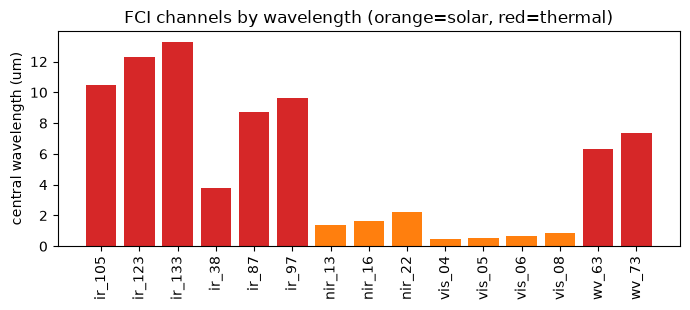

In [4]:
colors = {"solar": "tab:orange", "thermal": "tab:red"}
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(
    channel_table.index,
    channel_table["wavelength_um"],
    color=[colors[k] for k in channel_table["kind"]],
)
ax.set_ylabel("central wavelength (um)")
ax.set_title("FCI channels by wavelength (orange=solar, red=thermal)")
ax.tick_params(axis="x", rotation=90)
fig.tight_layout()

## Solar bands - `radiance_to_reflectance`

For a reflective band the top-of-atmosphere bidirectional reflectance factor is

`rho = pi * L * d^2 / E0`

where `L` is the measured radiance, `d` the sun-earth distance (AU) and `E0` the
band-integrated solar irradiance. The conversion is linear in radiance, so a brighter
scene maps straight to a higher reflectance.

| argument | meaning | typical value |
| --- | --- | --- |
| `radiance` | measured spectral radiance `L` | scene-dependent |
| `solar_irradiance` | band solar irradiance `E0` | from the channel table |
| `sun_earth_distance` | `d` in AU | ~0.983-1.017 over a year |
| `cos_sza` | cosine of the solar zenith angle | `None` to skip |

In [5]:
vis06 = fci.get_channel("vis_06")
radiance = np.linspace(0, 250, 200)
reflectance = radiance_to_reflectance(radiance, vis06.solar_irradiance)
print("E0 =", vis06.solar_irradiance, "W m-2 um-1")
print("reflectance at L=150:", round(float(reflectance[radiance.searchsorted(150)]), 3))

E0 = 1580.0 W m-2 um-1
reflectance at L=150: 0.3


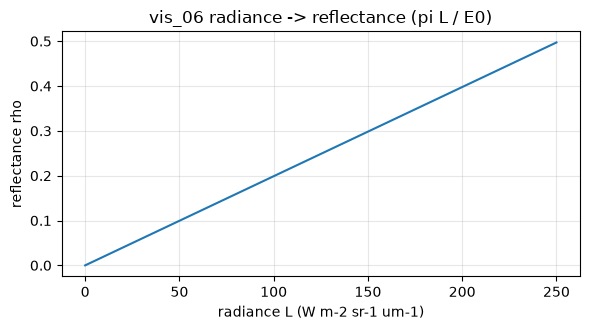

In [6]:
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(radiance, reflectance)
ax.set_xlabel("radiance L (W m-2 sr-1 um-1)")
ax.set_ylabel("reflectance rho")
ax.set_title("vis_06 radiance -> reflectance (pi L / E0)")
ax.grid(alpha=0.3)
fig.tight_layout()

### The sun-angle correction

Passing `cos_sza` divides by the cosine of the solar zenith angle to normalise for how
obliquely the Sun illuminates each pixel. Past the terminator the Sun is below the
horizon (`cos_sza <= 0`) and the correction is undefined, so those pixels are returned
as `NaN` rather than a spurious huge value — clean nodata the compositor can mask.

In [7]:
sza_deg = np.linspace(0, 100, 200)
cos_sza = np.cos(np.deg2rad(sza_deg))
corrected = radiance_to_reflectance(100.0, vis06.solar_irradiance, cos_sza=cos_sza)
n_nan = int(np.isnan(corrected).sum())
print(f"{n_nan} of {corrected.size} pixels are NaN (Sun below the horizon)")

20 of 200 pixels are NaN (Sun below the horizon)


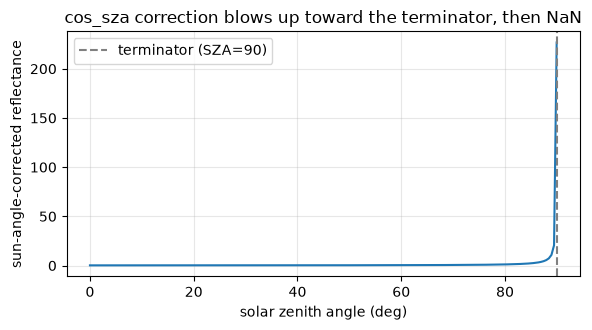

In [8]:
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(sza_deg, corrected)
ax.axvline(90, color="grey", ls="--", label="terminator (SZA=90)")
ax.set_xlabel("solar zenith angle (deg)")
ax.set_ylabel("sun-angle-corrected reflectance")
ax.set_title("cos_sza correction blows up toward the terminator, then NaN")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

## Thermal bands - `radiance_to_brightness_temperature`

For an emissive band the radiance is inverted through the Planck function to the
temperature a blackbody would need to emit it — the **brightness temperature**. This
uses the EUMETSAT effective-radiance form

`Tb* = C2 * nu / ln(1 + C1 * nu^3 / L)`, then `Tb = (Tb* - beta) / alpha`

with `nu` the channel central wavenumber and `alpha`/`beta` the per-channel band
correction. Unlike reflectance it is strongly non-linear: cold cloud tops sit at the
low-radiance end, warm surfaces at the high end.

In [9]:
ir105 = fci.get_channel("ir_105")
radiance_ir = np.linspace(5, 120, 200)
bt = radiance_to_brightness_temperature(
    radiance_ir, ir105.central_wavenumber_cm1, ir105.alpha, ir105.beta
)
print("nu =", ir105.central_wavenumber_cm1, "cm-1")
print("BT span (K):", round(float(bt.min()), 1), "->", round(float(bt.max()), 1))

nu = 952.4 cm-1
BT span (K): 179.6 -> 307.0


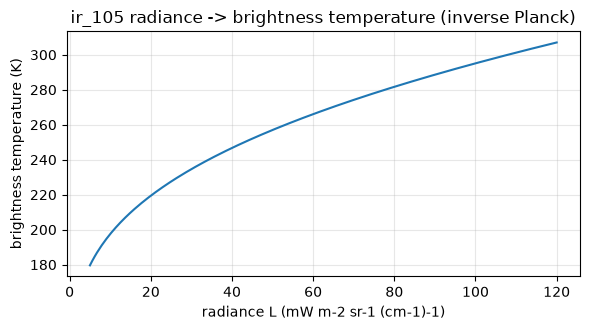

In [10]:
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(radiance_ir, bt)
ax.set_xlabel("radiance L (mW m-2 sr-1 (cm-1)-1)")
ax.set_ylabel("brightness temperature (K)")
ax.set_title("ir_105 radiance -> brightness temperature (inverse Planck)")
ax.grid(alpha=0.3)
fig.tight_layout()

Non-positive radiance has no valid temperature, so it maps to `NaN` instead of raising
- again giving the downstream compositor clean nodata rather than a crash.

In [11]:
edge = radiance_to_brightness_temperature(
    np.array([-1.0, 0.0, 50.0]), ir105.central_wavenumber_cm1
)
print("BT of [-1, 0, 50]:", np.round(edge, 2).tolist())

BT of [-1, 0, 50]: [nan, nan, 257.01]


## One call - `calibrate_channel`

The readers do not call the two physics functions directly; they call
`calibrate_channel`, which looks up the channel in the registry, dispatches on its
`kind`, and pulls each constant from the granule's own `coeffs` when supplied, falling
back to the registry table otherwise. That is exactly what makes the readers
granule-accurate when metadata is present and still usable when it is not.

In [12]:
radiance_ir = np.full((2, 2), 80.0)
bt = calibrate_channel(radiance_ir, "ir_105", "fci", 1.0, None)
refl = calibrate_channel(np.full((2, 2), 120.0), "vis_06", "fci", 1.0, None)
print("ir_105 -> brightness temperature (K):", round(float(bt[0, 0]), 2))
print("vis_06 -> reflectance:", round(float(refl[0, 0]), 3))

ir_105 -> brightness temperature (K): 281.69
vis_06 -> reflectance: 0.239


Passing `coeffs` overrides any registry constant with the granule's real value. Here a
granule-supplied wavenumber and band correction change the brightness temperature away
from the nominal-table result.

In [13]:
nominal = calibrate_channel(radiance_ir, "ir_105", "fci", 1.0, None)
granule = calibrate_channel(
    radiance_ir,
    "ir_105",
    "fci",
    1.0,
    None,
    coeffs={"central_wavenumber_cm1": 900.0, "alpha": 0.99, "beta": 0.5},
)
print("nominal BT (K):", round(float(nominal[0, 0]), 2))
print("granule BT (K):", round(float(granule[0, 0]), 2))

nominal BT (K): 281.69
granule BT (K): 278.01


## Takeaway

- `get_sensor(name)` is the metadata entry point: a cached `Sensor` of frozen `Channel`
  records with wavelength, resolution, kind, and nominal calibration constants.
- `radiance_to_reflectance` (solar) and `radiance_to_brightness_temperature` (thermal)
  are the exact physics; both return `NaN` for undefined pixels (terminator /
  non-positive radiance) so nodata stays clean.
- `calibrate_channel` is the one call the readers use — it dispatches on channel kind and
  prefers per-granule `coeffs` over the registry fallback.

Next: [The FCI / SEVIRI readers and `harmonise`](readers_fci_seviri_harmonise.ipynb)
put this calibration to work on stitched, geolocated scenes.